# Individual Experiment Ratemap Analysis

Analyzes the ratemap progression of a single autoencoder instance (one experiment) across
its full training timeline. Loads the cached ratemaps produced by Ratemap_extraction
(the 301 checkpoint stack: untrained model plus 100 epochs per environment, three
environments) and computes how the latent representation evolves epoch by epoch.

Set `experiment_n` and `control` at the top to pick which cached experiment to read.
The notebook then reports the training loss curve, per checkpoint metrics (active unit
count, mean unit coverage, summed activity and active unit counts at four representative
maze locations, and map to map correlation across consecutive checkpoints), example image
reconstructions at epochs 0/10/100 in each environment, and the ratemap progression of a
handful of example units.

Reads from `Models/Experiment1/<Control|Experimental>/...Exp{n}_cache_ratemaps/ratemaps.npy` and
writes figures to `Plots/Experiment1/Example-[Control-]Experiment{n}/` when `save_plots` is True.

### Import libraries

In [2]:
%matplotlib inline
import os
import sys
import csv
import pathlib
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

### Import Autoencoder class

In [4]:
folder_path = str(pathlib.Path().resolve().parents[1])
data_path = 'D:\RORcogmaps_data'
print("Folder path =", folder_path)
sys.path.append(folder_path + '/Notebooks/Spatial_AE/')

from analysis import *
from plotting import *
from data import *

Folder path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps


### Check GPU

In [6]:
print("CUDA is available =", torch.cuda.is_available())
print("CUDA device count =", torch.cuda.device_count())
if torch.cuda.device_count() > 1:
    os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("CUDA device name =", torch.cuda.get_device_name(0))

CUDA is available = True
CUDA device count = 2
CUDA device name = NVIDIA RTX A5000


### Hyperparameters

In [8]:
experiment_n = 1
control = False
save_plots = False
normalize_ratemaps = True

#Model
n_hidden = 200
batch_size = 256
num_epochs = 100
learning_rate = 1e-4
C_factor = 1e3
alpha = 1e5

#Others
trial_t = 0

if control == False:
    envs = ['Tmaze_0', 'Tmaze_1', 'Tmaze_2']
else:
    envs = ['Tmaze_v0a', 'Tmaze_v0b', 'Tmaze_v0c']

In [9]:
if control == False:
    plot_folder_path = folder_path + '/Plots/Experiment1/Example-Experiment{}'.format(experiment_n)
else:
    plot_folder_path = folder_path + '/Plots/Experiment1/Example-Control-Experiment{}'.format(experiment_n)

os.makedirs(plot_folder_path, exist_ok=True)

### Import ratemaps

In [11]:
if control == True:
    CACHE_DIR = data_path + "/Models/Experiment1/Control/Control-Exp" + str(experiment_n) + "_cache_ratemaps"
else:
    CACHE_DIR = data_path + "/Models/Experiment1/Experimental/Exp" + str(experiment_n) + "_cache_ratemaps"
    
cache_path = os.path.join(CACHE_DIR, f"ratemaps.npy")

arr = np.load(cache_path, mmap_mode="r")  # no full load into RAM
print('arr shape =', arr.shape)

arr shape = (301, 200, 50, 50)


In [12]:
#Normalize ratemaps
if normalize_ratemaps == True:
    normal_arr = []
    
    for mt in range(len(arr)):
        mt_arr = []
        for unit in range(n_hidden):
            ratemap = arr[mt][unit]
            if np.max(ratemap) != 0.0:
                mt_arr.append(ratemap / np.max(ratemap))
            else:
                mt_arr.append(ratemap)
    
        normal_arr.append(mt_arr)
    
    arr = np.array(normal_arr)

In [13]:
loss_csv_filename = CACHE_DIR + '/loss_history.csv'

history_loss = []
with open(loss_csv_filename, mode='r', newline='') as file:
    reader = csv.DictReader(file)
    for row in reader:
        value = row.get('Image_loss')
        history_loss.append(float(value))

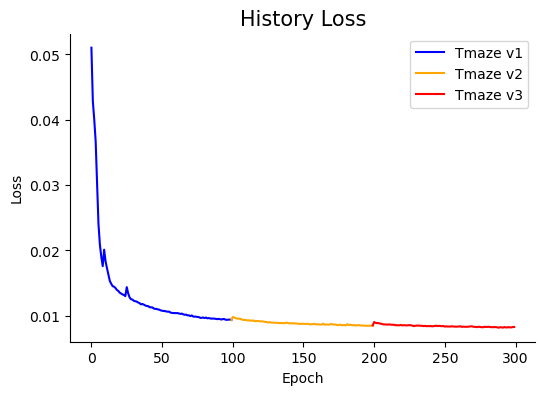

In [14]:
plot_history_loss(history_loss, save_plots=save_plots, path=plot_folder_path)

### Explore ratemaps at environment m and trial t

In [65]:
trial_idx = 99
trial_ratemaps = arr[trial_idx]
trial_ratemaps.shape

(200, 50, 50)

In [17]:
plot_ratemaps(trial_ratemaps[:100], path=plot_folder_path, save=save_plots)

In [18]:
peak_activity = []
for i in range(n_hidden):
    peak_activity.append(np.max(arr[trial_idx][i]))

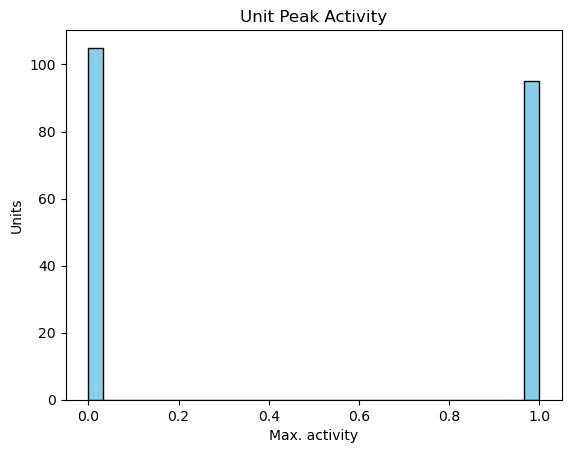

Silent units = 105.0


In [19]:
hist = plt.hist(peak_activity, bins=30, color='skyblue', edgecolor='black')

# Adding labels and title
plt.xlabel('Max. activity')
plt.ylabel('Units')
plt.title('Unit Peak Activity')

# Display the plot
plt.show()

print('Silent units =', hist[0][0])

In [20]:
actv_threshold = 0.01
num_active_units = []
mean_unit_coverage_history = []

TL_rep_unit_sum_history = []
TC_rep_unit_sum_history = []
TR_rep_unit_sum_history = []
BC_rep_unit_sum_history = []

TL_rep_unit_count_history = []
TC_rep_unit_count_history = []
TR_rep_unit_count_history = []
BC_rep_unit_count_history = []

correlation_history = []

for t in range(arr.shape[0]):
    if t == 0:
        max_coverage = get_max_coverage(arr[t], actv_threshold)
    
    num_active_units.append(get_num_active_units(arr[t], actv_threshold))
    mean_unit_coverage_history.append(get_mean_unit_coverage_at_t(arr[t], max_coverage, actv_threshold))

    # Unit activity at representative locations
    TL_sum, TC_sum, TR_sum, BC_sum = representative_unit_sums(arr[t])
    TL_rep_unit_sum_history.append(TL_sum)
    TC_rep_unit_sum_history.append(TC_sum)
    TR_rep_unit_sum_history.append(TR_sum)
    BC_rep_unit_sum_history.append(BC_sum)
    
    TL_count, TC_count, TR_count, BC_count = representative_unit_count(arr[t], actv_threshold)
    TL_rep_unit_count_history.append(TL_count)
    TC_rep_unit_count_history.append(TC_count)
    TR_rep_unit_count_history.append(TR_count)
    BC_rep_unit_count_history.append(BC_count)

    # Measure map correlation
    if t != 0:
        flat_t0 = prev_ratemaps.flatten()
        flat_t1 = arr[t].flatten()
        corr = np.corrcoef(flat_t0, flat_t1)[0, 1]
        correlation_history.append(corr)

    prev_ratemaps = arr[t]
    

Max. coverage = 1851


## Serial results

In [22]:
mean_unit_coverage = [x * 100 for x in mean_unit_coverage_history] #Compute percentages

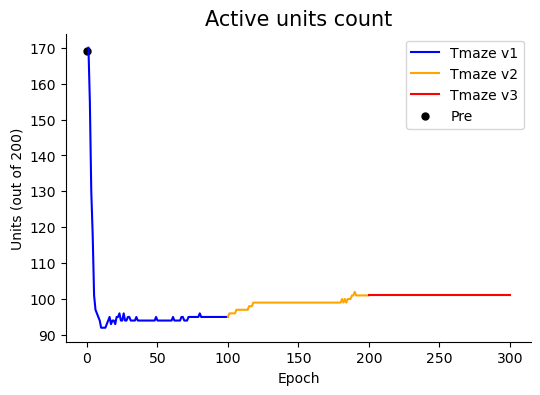

In [23]:
plot_active_units_count(num_active_units, nhidden=n_hidden, save=save_plots, path=plot_folder_path)

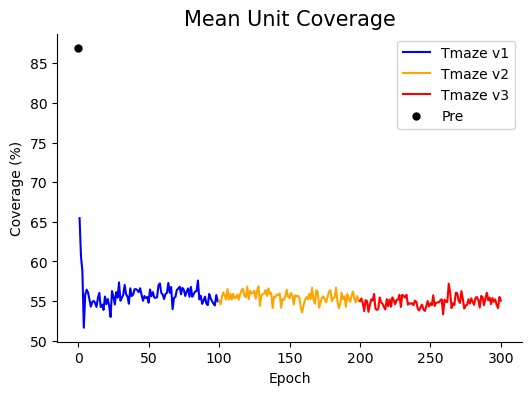

In [24]:
plot_unit_coverage(mean_unit_coverage, save=save_plots, path=plot_folder_path)

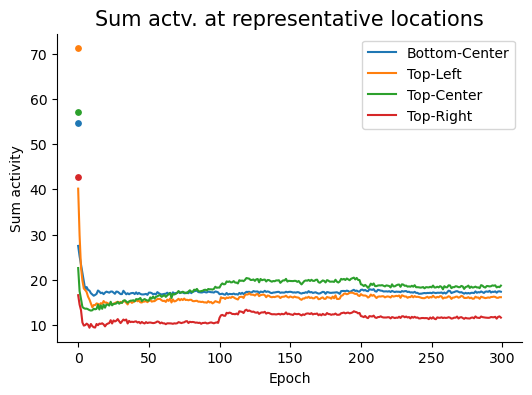

In [25]:
plot_activity_rep_loc(BC_rep_unit_sum_history, TL_rep_unit_sum_history, TC_rep_unit_sum_history, TR_rep_unit_sum_history, save=save_plots, path=plot_folder_path)

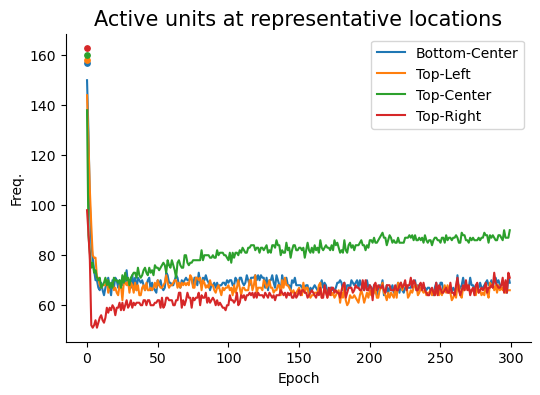

In [26]:
plot_units_rep_loc(BC_rep_unit_count_history, TL_rep_unit_count_history, TC_rep_unit_count_history, TR_rep_unit_count_history, save=save_plots, path=plot_folder_path)

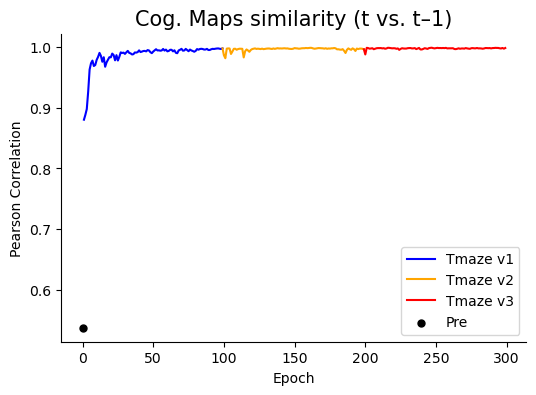

In [27]:
plot_cogmap_correlation(correlation_history, save=save_plots, path=plot_folder_path)

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_v0a
Num. Images in Dataset = 39998
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/Tmaze_v0a
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/Tmaze_v0a/data.csv

Dataset Shape  = (39998, 120, 160, 3)


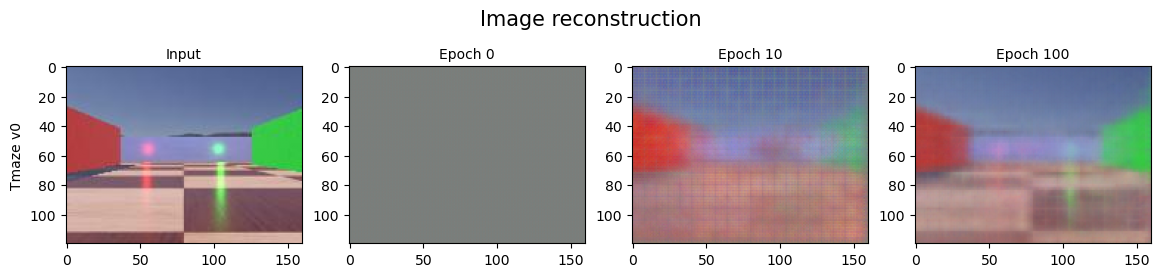

In [28]:
img_idx = 0

m = 0
env = envs[m]
foldername = 'Exp' + str(experiment_n) + '-NEpisodes' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate)

model_filename =  env + '-Trial' + str(0) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m0t0 = update_model_trial(control, experiment_n, env, trial=0, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)
model_filename =  env + '-Trial' + str(10) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m0t10 = update_model_trial(control, experiment_n, env, trial=10, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)
model_filename =  env + '-Trial' + str(100) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m0t100 = update_model_trial(control, experiment_n, env, trial=100, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)

dataset, _ = Load_env_dataset(folder_path, env)
m0_input = dataset[img_idx]

plot_img_reconstruction(m, m0_input, m0t0, m0t10, m0t100, m0_bool=True, save=save_plots, path=plot_folder_path)

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_v0b
Num. Images in Dataset = 39998
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/Tmaze_v0b
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/Tmaze_v0b/data.csv

Dataset Shape  = (39998, 120, 160, 3)


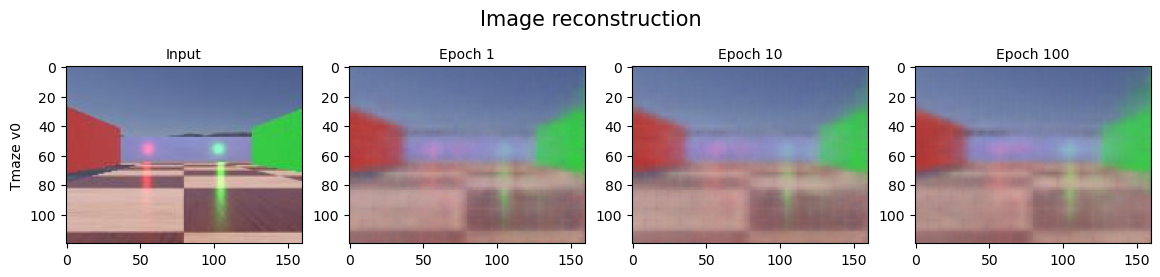

In [29]:
m = 1
env = envs[m]

model_filename =  env + '-Trial' + str(1) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m1t0 = update_model_trial(control, experiment_n, env, trial=1, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)
model_filename =  env + '-Trial' + str(10) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m1t10 = update_model_trial(control, experiment_n, env, trial=10, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)
model_filename =  env + '-Trial' + str(100) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m1t100 = update_model_trial(control, experiment_n, env, trial=100, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)

dataset, _ = Load_env_dataset(folder_path, env)
m1_input = dataset[img_idx]

plot_img_reconstruction(m, m1_input, m1t0, m1t10, m1t100, save=save_plots, path=plot_folder_path)

----------  ----------  NEW ENVIRONMENT ----------  ----------
Dataset Environment    = Tmaze_v0c
Num. Images in Dataset = 39998
Dataset Path = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/Tmaze_v0c
CSV path     = C:\Users\specs\Desktop\Robotology\Repos\RORcogmaps/Datasets/Tmaze_v0c/data.csv

Dataset Shape  = (39998, 120, 160, 3)


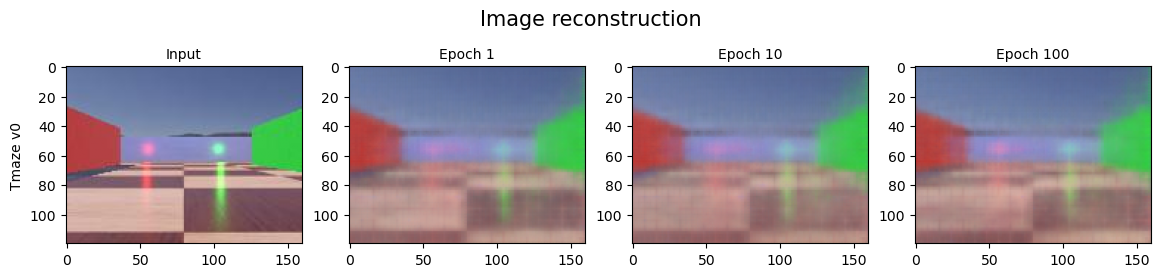

In [30]:
m = 2
env = envs[m]

model_filename =  env + '-Trial' + str(1) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m2t0 = update_model_trial(control, experiment_n, env, trial=1, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)
model_filename =  env + '-Trial' + str(10) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m2t10 = update_model_trial(control, experiment_n, env, trial=10, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)
model_filename =  env + '-Trial' + str(100) + 'of' + str(num_epochs) + '-NHidden' + str(n_hidden) + '-BSize' + str(batch_size) + '-C' + str(C_factor) + '-A' + str(alpha) + '-LR' + str(learning_rate) + '.pth'
m2t100 = update_model_trial(control, experiment_n, env, trial=100, model_filename=model_filename, foldername=foldername, folder_path=data_path, n_hidden=n_hidden)

dataset, _ = Load_env_dataset(folder_path, env)
m2_input = dataset[img_idx]

plot_img_reconstruction(m, m2_input, m2t0, m2t10, m2t100, save=save_plots, path=plot_folder_path)

In [31]:
unit_1 = 1
unit_2 = 50
unit_3 = 100
unit_4 = 150
unit_5 = 199

In [32]:
m0t0_ratemap1 = arr[0][unit_1]
m0t0_ratemap2 = arr[0][unit_2]
m0t0_ratemap3 = arr[0][unit_3]
m0t0_ratemap4 = arr[0][unit_4]
m0t0_ratemap5 = arr[0][unit_5]

m0t10_ratemap1 = arr[10][unit_1]
m0t10_ratemap2 = arr[10][unit_2]
m0t10_ratemap3 = arr[10][unit_3]
m0t10_ratemap4 = arr[10][unit_4]
m0t10_ratemap5 = arr[10][unit_5]

m0t100_ratemap1 = arr[100][unit_1]
m0t100_ratemap2 = arr[100][unit_2]
m0t100_ratemap3 = arr[100][unit_3]
m0t100_ratemap4 = arr[100][unit_4]
m0t100_ratemap5 = arr[100][unit_5]
####################################

m1t1_ratemap1 = arr[101][unit_1]
m1t1_ratemap2 = arr[101][unit_2]
m1t1_ratemap3 = arr[101][unit_3]
m1t1_ratemap4 = arr[101][unit_4]
m1t1_ratemap5 = arr[101][unit_5]

m1t10_ratemap1 = arr[110][unit_1]
m1t10_ratemap2 = arr[110][unit_2]
m1t10_ratemap3 = arr[110][unit_3]
m1t10_ratemap4 = arr[110][unit_4]
m1t10_ratemap5 = arr[110][unit_5]

m1t100_ratemap1 = arr[200][unit_1]
m1t100_ratemap2 = arr[200][unit_2]
m1t100_ratemap3 = arr[200][unit_3]
m1t100_ratemap4 = arr[200][unit_4]
m1t100_ratemap5 = arr[200][unit_5]
####################################

m2t1_ratemap1 = arr[201][unit_1]
m2t1_ratemap2 = arr[201][unit_2]
m2t1_ratemap3 = arr[201][unit_3]
m2t1_ratemap4 = arr[201][unit_4]
m2t1_ratemap5 = arr[201][unit_5]

m2t10_ratemap1 = arr[210][unit_1]
m2t10_ratemap2 = arr[210][unit_2]
m2t10_ratemap3 = arr[210][unit_3]
m2t10_ratemap4 = arr[210][unit_4]
m2t10_ratemap5 = arr[210][unit_5]

m2t100_ratemap1 = arr[300][unit_1]
m2t100_ratemap2 = arr[300][unit_2]
m2t100_ratemap3 = arr[300][unit_3]
m2t100_ratemap4 = arr[300][unit_4]
m2t100_ratemap5 = arr[300][unit_5]

example_units = [unit_1, unit_2, unit_3, unit_4, unit_5]

example_ratemaps = [[m0t0_ratemap1, m0t0_ratemap2, m0t0_ratemap3, m0t0_ratemap4, m0t0_ratemap5],
                    [m0t10_ratemap1, m0t10_ratemap2, m0t10_ratemap3,m0t10_ratemap4, m0t10_ratemap5],
                    [m0t100_ratemap1, m0t100_ratemap2, m0t100_ratemap3, m0t100_ratemap4, m0t100_ratemap5],
                    [m1t1_ratemap1, m1t1_ratemap2, m1t1_ratemap3, m1t1_ratemap4, m1t1_ratemap5],
                    [m1t10_ratemap1, m1t10_ratemap2, m1t10_ratemap3, m1t10_ratemap4, m1t10_ratemap5],
                    [m1t100_ratemap1, m1t100_ratemap2, m1t100_ratemap3, m1t100_ratemap4, m1t100_ratemap5],
                    [m2t1_ratemap1, m2t1_ratemap2, m2t1_ratemap3, m2t1_ratemap4, m2t1_ratemap5], 
                    [m2t10_ratemap1, m2t10_ratemap2, m2t10_ratemap3, m2t10_ratemap4, m2t10_ratemap5],
                    [m2t100_ratemap1, m2t100_ratemap2, m2t100_ratemap3, m2t100_ratemap4, m2t100_ratemap5]]

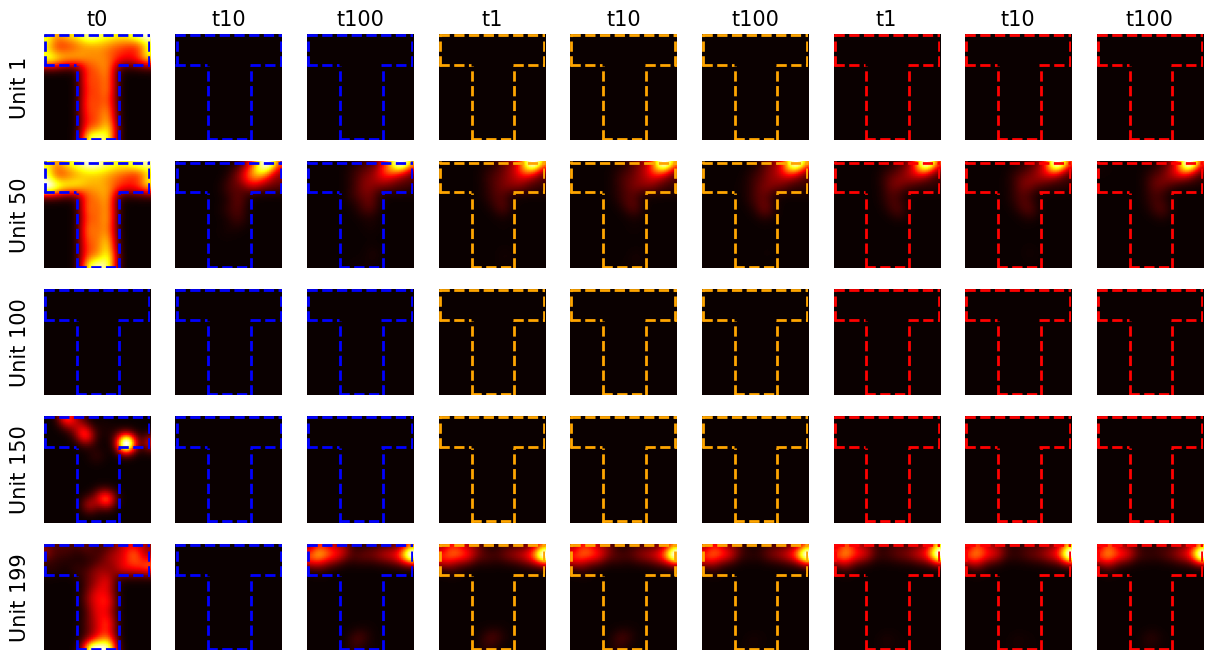

In [33]:
plot_example_ratemaps_progress(example_units, example_ratemaps, save=save_plots, path=plot_folder_path)